# Emoji Sentiment

Are popular emojis generally associated with positive or negative sentiments?

The file `"emoji-sentiment.csv"` provides data on the sentiment associated with various emojis.

Researchers examined 1.6 million tweets across 13 European languages. Each tweet was labeled by annotators as positive (+1), negative (-1), or neutral (0). About 4% of these tweets included emojis.

Columns include:
- `Occurrences [5...max]`: Number of times the emoji appears in the dataset.
- `Position [0...1]`: Average position of the emoji in tweets, from start (0) to end (1).
- `Neg [0...1]`: Percentage of tweets with the emoji that are 'negative'.
- `Neu [0...1]`: Percentage of tweets with the emoji that are 'neutral'.
- `Pos [0...1]`: Percentage of tweets with the emoji that are 'positive'.



In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'emoji-sentiment.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
df = pd.read_csv('emoji-sentiment.csv')
df.head(3)

,Char,Image [twemoji],Unicode codepoint,Occurrences [5...max],Position [0...1],Neg [0...1],Neut [0...1],Pos [0...1],Sentiment bar (c.i. 95%),Unicode name,Unicode block
0,😂,😂,0x1f602,14622,0.805,0.247,0.285,0.468,NaN,FACE WITH TEARS OF JOY,Emoticons
1,❤,❤,0x2764,8050,0.747,0.044,0.166,0.790,NaN,HEAVY BLACK HEART,Dingbats
2,♥,♥,0x2665,7144,0.754,0.035,0.272,0.693,NaN,BLACK HEART SUIT,Miscellaneous Symbols


### Project Ideas:

Data Cleaning: 
- Remove unnecessary columns that are not useful for your analysis.

- Rename the remaining columns using `snake_case` (all lowercase letters with underscores between words).

New Variables:
- Add a new column called `sentiment`, where sentiment = (% positive tweets) - (% negative tweets).

- Add a `positive_flag` column that is `True` if `sentiment > 0` (or above a set threshold), otherwise `False`.

Types of questions you can now answer more easily:
- What percentage of emojis in the dataset have a positive sentiment?

- What percentage of the top 20 most popular emojis are positive?

- Which emoji (with more than 500 mentions) is the most positive?

- Which emoji (with more than 500 mentions) is the most negative?

- Where in the tweets are most emojis located (i.e. at the beginning or the end)?

- Is there a difference in the placement of positive versus negative emojis within a tweet?

In [3]:
# YOUR CODE HERE (add additional cells as needed)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Char                      751 non-null    str    
 1   Image [twemoji]           751 non-null    str    
 2   Unicode codepoint         751 non-null    str    
 3   Occurrences [5...max]     751 non-null    int64  
 4   Position [0...1]          751 non-null    float64
 5   Neg [0...1]               751 non-null    float64
 6   Neut [0...1]              751 non-null    float64
 7   Pos [0...1]               751 non-null    float64
 8   Sentiment bar (c.i. 95%)  0 non-null      float64
 9   Unicode name              751 non-null    str    
 10  Unicode block             751 non-null    str    
dtypes: float64(5), int64(1), str(5)
memory usage: 64.7 KB


In [5]:
df = df.drop(
    columns=[
        "Image [twemoji]",
        "Sentiment bar (c.i. 95%)"
    ]
)

In [6]:
print(df.columns)

Index(['Char', 'Unicode codepoint', 'Occurrences [5...max]',
       'Position [0...1]', 'Neg [0...1]', 'Neut [0...1]', 'Pos [0...1]',
       'Unicode name', 'Unicode block'],
      dtype='str')


In [10]:
df.columns = [
    "char",
    "unicode_codepoint",
    "occurrences",
    "position",
    "neg",
    "neut",
    "pos",
    "unicode_name",
    "unicode_block"
]

In [11]:
print(df.columns)

Index(['char', 'unicode_codepoint', 'occurrences', 'position', 'neg', 'neut',
       'pos', 'unicode_name', 'unicode_block'],
      dtype='str')


In [12]:
df["sentiment"] = (
    df["pos"] -
    df["neg"]
)

In [13]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

In [15]:
df["positive_flag"] = (
    df["sentiment"] > 0
)

In [16]:
positive_percent = (
    df["positive_flag"]
    .mean()
) * 100

print(positive_percent)

82.42343541944075


In [18]:
top20 = df.sort_values(
    "occurrences",
    ascending=False
).head(20)


In [19]:
top20_positive = (
    top20["positive_flag"]
    .mean()
) * 100

print(top20_positive)

90.0


In [20]:
popular = df[
    df["occurrences"] > 500
]

In [21]:
most_positive = popular.loc[
    popular["sentiment"].idxmax()
]

print(most_positive)

char                                 ❤
unicode_codepoint               0x2764
occurrences                       8050
position                         0.747
neg                              0.044
neut                             0.166
pos                               0.79
unicode_name         HEAVY BLACK HEART
unicode_block                 Dingbats
sentiment                        0.746
positive_flag                     True
Name: 1, dtype: object


In [22]:
print(
    most_positive[
        ["char", "sentiment"]
    ]
)

char             ❤
sentiment    0.746
Name: 1, dtype: object


In [23]:
most_negative = popular.loc[
    popular["sentiment"].idxmin()
]

print(
    most_negative[
        ["char", "sentiment"]
    ]
)

char             😒
sentiment   -0.374
Name: 23, dtype: object


In [30]:
position_01 = df["position"]
avg_position = position_01.mean()
print(avg_position)


0.6655486018641811


In [39]:
positive_pos = df.loc[df["positive_flag"], "position"].mean()


In [68]:
negative_pos = df.loc[~df["positive_flag"], "position"].mean()

In [69]:
print("Positive:", positive_pos)
print("Negative:", negative_pos)

Positive: 0.662248788368336
Negative: 0.6810227272727273


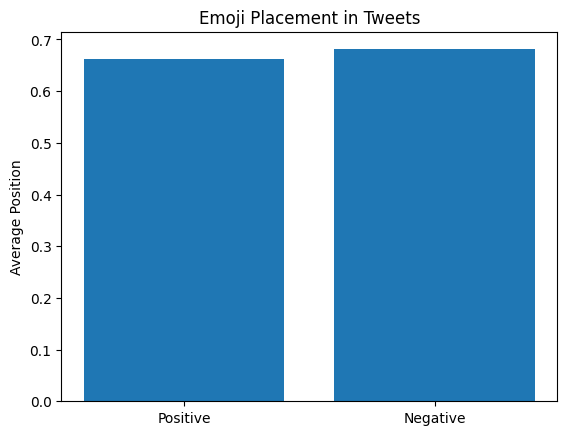

In [70]:
import matplotlib.pyplot as plt

labels = [
    "Positive",
    "Negative"
]

values = [
    positive_pos,
    negative_pos
]

plt.bar(labels, values)

plt.ylabel(
    "Average Position"
)

plt.title(
    "Emoji Placement in Tweets"
)

plt.show()

<Axes: xlabel='char'>

d:\harsh\cisco\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128076 (\N{OK HAND SIGN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\harsh\cisco\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\harsh\cisco\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128079 (\N{CLAPPING HANDS SIGN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\harsh\cisco\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\harsh\cisco\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128591 (\N{PERSON WITH FOLDED HANDS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\harsh\cisco\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128588 (\N{PERSON RAISING BOTH HANDS IN CELEB

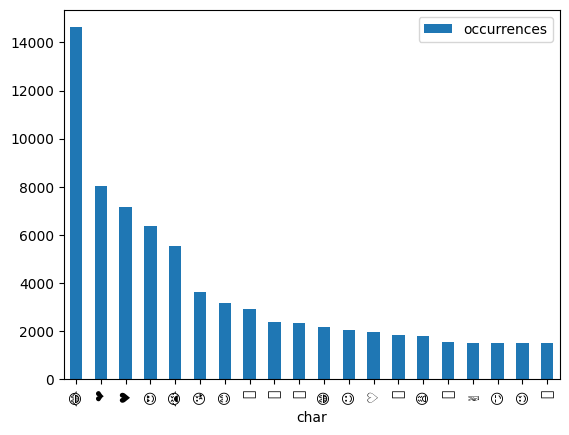

In [71]:
top20.plot.bar(
    x="char",
    y="occurrences"
)

<Axes: ylabel='Frequency'>

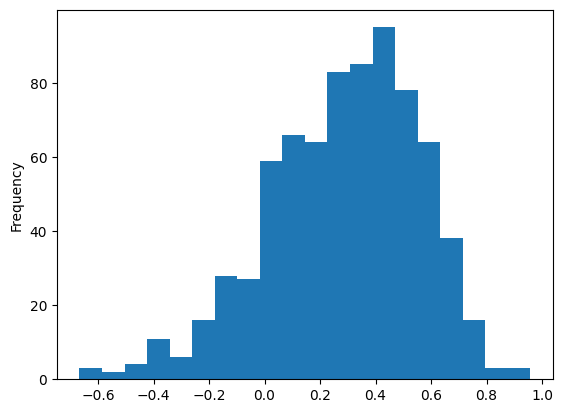

In [72]:
df["sentiment"].plot.hist(
    bins=20
)

<Axes: >

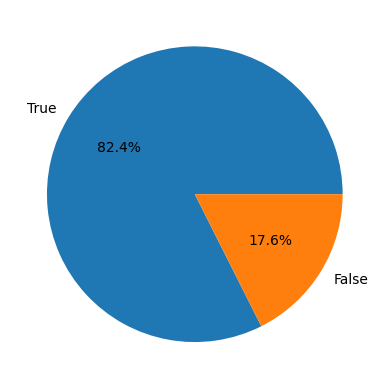

In [73]:
df["positive_flag"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

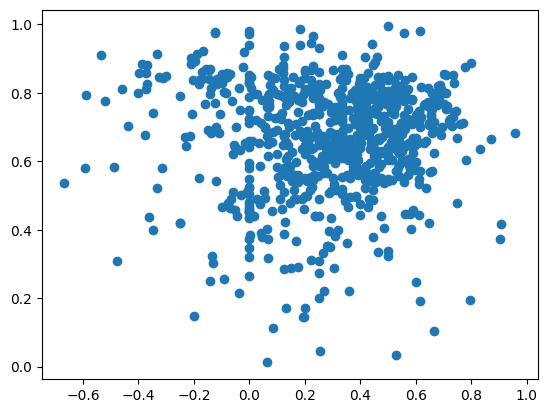

In [76]:
plt.scatter(
    df["sentiment"],
    df["position"]
)

In [77]:
df.groupby(
    "unicode_block"
)["sentiment"].mean()

unicode_block
Arabic                                   0.000000
Arrows                                   0.279571
Block Elements                           0.019273
Box Drawing                              0.147800
Braille Patterns                         0.046000
Dingbats                                 0.253773
Emoticons                                0.171039
Enclosed Alphanumeric Supplement         0.410000
Enclosed Alphanumerics                   0.204000
Enclosed Ideographic Supplement          0.292000
Geometric Shapes                         0.264917
Latin-1 Supplement                       0.325667
Miscellaneous Symbols                    0.262645
Miscellaneous Symbols and Arrows         0.430000
Miscellaneous Symbols and Pictographs    0.330565
Miscellaneous Technical                  0.231000
Playing Cards                            0.084000
Specials                                -0.194500
Transport and Map Symbols                0.238605
Name: sentiment, dtype: float64

In [79]:
df.loc[
    df["sentiment"].abs().idxmin()
]

char                                                     💶
unicode_codepoint                                  0x1f4b6
occurrences                                             22
position                                             0.748
neg                                                   0.16
neut                                                  0.68
pos                                                   0.16
unicode_name                       BANKNOTE WITH EURO SIGN
unicode_block        Miscellaneous Symbols and Pictographs
sentiment                                              0.0
positive_flag                                        False
Name: 444, dtype: object